In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

EUROSAT_ROOT = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'
UCMERCED_ROOT = '/kaggle/input/datasets/abdulhasibuddin/uc-merced-land-use-dataset/UCMerced_LandUse/Images'

eurosat_root = Path(EUROSAT_ROOT)
classes = sorted([d.name for d in eurosat_root.iterdir() if d.is_dir()])

records = []
for c in classes:
    for f in (eurosat_root / c).glob('*.jpg'):
        records.append({'path': str(f), 'class': c})
df = pd.DataFrame(records)

df['file_idx'] = df['path'].apply(lambda p: int(Path(p).stem.split('_')[-1]))
df['block_id'] = df['file_idx'] // 9

blocks = df['block_id'].unique()
np.random.shuffle(blocks)
n = len(blocks)
train_blocks = blocks[:int(0.7*n)]
val_blocks = blocks[int(0.7*n):int(0.85*n)]

df['split_block'] = df['block_id'].apply(
    lambda b: 'train' if b in train_blocks else ('val' if b in val_blocks else 'test')
)
df['split_random'] = np.random.choice(['train','val','test'], size=len(df), p=[0.7,0.15,0.15])

print(len(df))
print(df['split_block'].value_counts())

27000
split_block
train    18694
val       4175
test      4131
Name: count, dtype: int64


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[row['class']]
        return img, label

train_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_df = df[df['split_block'] == 'train']
val_df   = df[df['split_block'] == 'val']
test_df  = df[df['split_block'] == 'test']

train_ds = EuroSATDataset(train_df, transform=train_tf)
val_ds   = EuroSATDataset(val_df, transform=eval_tf)
test_ds  = EuroSATDataset(test_df, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

18694 4175 4131


In [11]:
import torch.nn as nn
import torch.optim as optim

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = BaselineCNN(num_classes=10).to(device)
print(device)

cpu


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
val_accs = []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    val_loss = val_loss / len(val_ds)
    val_acc = correct / len(val_ds)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"epoch {epoch+1}/{num_epochs} - train_loss {train_loss:.4f} - val_loss {val_loss:.4f} - val_acc {val_acc:.4f}")

epoch 1/10 - train_loss 1.3273 - val_loss 1.0336 - val_acc 0.6299
epoch 2/10 - train_loss 0.8472 - val_loss 0.7381 - val_acc 0.7291
epoch 3/10 - train_loss 0.7088 - val_loss 0.6282 - val_acc 0.7708
epoch 4/10 - train_loss 0.6618 - val_loss 0.5650 - val_acc 0.7974
epoch 5/10 - train_loss 0.6312 - val_loss 0.5842 - val_acc 0.7957
epoch 6/10 - train_loss 0.5749 - val_loss 0.6847 - val_acc 0.7578
epoch 7/10 - train_loss 0.5166 - val_loss 0.5101 - val_acc 0.8172
epoch 8/10 - train_loss 0.4889 - val_loss 0.4966 - val_acc 0.8192
epoch 9/10 - train_loss 0.4609 - val_loss 0.4999 - val_acc 0.8244
epoch 10/10 - train_loss 0.4306 - val_loss 0.6665 - val_acc 0.7825


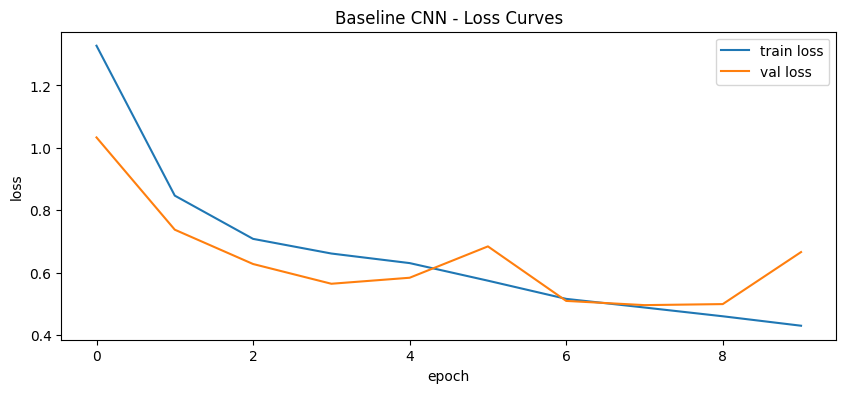

In [13]:
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Baseline CNN - Loss Curves')
plt.savefig('/kaggle/working/baseline_loss_curves.png')
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, digits=3))

                      precision    recall  f1-score   support

          AnnualCrop      0.584     0.933     0.718       449
              Forest      0.987     0.829     0.901       449
HerbaceousVegetation      0.715     0.744     0.729       449
             Highway      0.791     0.525     0.631       404
          Industrial      0.945     0.936     0.940       404
             Pasture      0.655     0.889     0.754       314
       PermanentCrop      0.634     0.569     0.600       404
         Residential      0.991     0.755     0.857       449
               River      0.848     0.636     0.727       404
             SeaLake      0.875     0.996     0.931       449

            accuracy                          0.783      4175
           macro avg      0.802     0.781     0.779      4175
        weighted avg      0.807     0.783     0.782      4175



In [19]:
torch.save(model.state_dict(), '/kaggle/working/baseline_cnn.pt')